# Resonate: model training

Train the **LightGCN** model used by Resonate on the processed Last.fm 360K dataset for music artist recommendation.

**LightGCN** (He et al., SIGIR 2020) strips graph convolution down to its essential component — neighbourhood aggregation — removing feature transformation and non-linear activation entirely.

### Architecture

| Component | Detail |
|---|---|
| Learnable parameters | Embedding table $E^{(0)} \in \mathbb{R}^{(n_u + n_i) \times d}$ |
| Propagation | $E^{(k)} = \tilde{A}\, E^{(k-1)}$, where $\tilde{A} = D^{-1/2} A D^{-1/2}$ |
| Final embedding | $E = \frac{1}{K+1}\sum_{k=0}^{K} E^{(k)}$ |
| Training loss | BPR (Bayesian Personalised Ranking) |

### Dataset (`data/`)

| | |
|---|---|
| Users | 358,619 |
| Artists | 87,660 |
| Train interactions | 13,738,532 |
| Test interactions | 3,434,608 |

## Setup

In [ ]:
# Install dependencies (run once if needed; required on Colab)
%pip install -q torch scipy tqdm matplotlib pandas

In [1]:
import time
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm, trange

warnings.filterwarnings("ignore")

# ── Device selection ──────────────────────────────────────────────────────────
# Sparse matmul (torch.sparse.mm) is run on CPU even when a GPU is available,
# because MPS/CUDA sparse support has limitations. Dense BPR ops use DEVICE.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"PyTorch {torch.__version__}")
print(f"Device : {DEVICE}")

PyTorch 2.10.0
Device : mps


## Configuration

### Colab: Mount Drive & set data path

Run this cell first. On Colab it will mount Google Drive and set `DATA_DIR` to your Drive data folder. Put your `data` folder (with `rec_dataset_summary.csv`, `rec_dataset.npz`, etc.) in **My Drive** and set `DRIVE_DATA_FOLDER` below if needed (e.g. `"resonate/data"` if inside a project folder).

In [ ]:
# ── Google Colab: mount Drive and set data path ─────────────────────────────────────
# Run this cell first. If your data folder is elsewhere on Drive, change DRIVE_DATA_FOLDER.
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
    DRIVE_DATA_FOLDER = "data"  # path under My Drive, e.g. "data" or "resonate/data"
    DATA_DIR = Path("/content/drive/MyDrive") / DRIVE_DATA_FOLDER
except ImportError:
    IN_COLAB = False
    DATA_DIR = Path("../data")

print(f"Running on Colab: {IN_COLAB}")
print(f"DATA_DIR = {DATA_DIR.resolve() if hasattr(DATA_DIR, 'resolve') else DATA_DIR}")

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# DATA_DIR is set in the previous cell (Google Drive on Colab, or ../data locally)

# ── Model ─────────────────────────────────────────────────────────────────────
EMBEDDING_DIM   = 128   # ↑ from 64: 446K nodes need more capacity
N_LAYERS        = 3     # keep: LightGCN paper found 3 optimal; denser graphs risk over-smoothing at 4+

# ── Training ──────────────────────────────────────────────────────────────────
N_EPOCHS        = 200   # ↓ from 300: each epoch now covers far more data
LR              = 1e-3  # keep
LAMBDA_REG      = 1e-4  # keep (try 1e-5 if validation loss plateaus high)
BATCH_SIZE      = 4096  # ↑ from 2048: reduces gradient noise on large graph
STEPS_PER_EPOCH = 2048  # ↑ from 500: 2048×4096 = 8.4M triplets/epoch ≈ 60% of train set

# ── Evaluation ────────────────────────────────────────────────────────────────
EVAL_K          = [10, 20, 50]   # add @50 for production ranking depth
EVAL_EVERY      = 5              # ↓ from 10: fewer total epochs, evaluate more often
N_EVAL_USERS    = 3000           # ↑ from 500: 500/358K = 0.14% is too noisy; 3K = 0.84%

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Load Data

In [3]:
# ── Summary ───────────────────────────────────────────────────────────────────
summary   = pd.read_csv(DATA_DIR / "rec_dataset_summary.csv")
n_users   = int(summary["n_users"].iloc[0])
n_items   = int(summary["n_items"].iloc[0])
n_train   = int(summary["n_train_edges"].iloc[0])
n_test    = int(summary["n_test_edges"].iloc[0])

print("Dataset summary")
print(f"  Users  : {n_users:>10,}")
print(f"  Artists: {n_items:>10,}")
print(f"  Train  : {n_train:>10,}")
print(f"  Test   : {n_test:>10,}")

# ── Load edges from .npz (binary, faster than CSVs) ──────────────────────────
print("\nLoading edges from rec_dataset.npz ...")
t0 = time.time()
data = np.load(DATA_DIR / "rec_dataset.npz")

train_users = data["train_user"].astype(np.int64)
train_items = data["train_item"].astype(np.int64)
test_users  = data["test_user"].astype(np.int64)
test_items  = data["test_item"].astype(np.int64)

print(f"  Loaded in {time.time() - t0:.1f}s")
print(f"  Train edges shape: {train_users.shape}")
print(f"  Test  edges shape: {test_users.shape}")

Dataset summary
  Users  :    358,619
  Artists:     87,660
  Train  : 13,738,532
  Test   :  3,434,624

Loading edges from rec_dataset.npz ...
  Loaded in 0.1s
  Train edges shape: (13738532,)
  Test  edges shape: (3434624,)


## 2. Build the User–Item Graph

LightGCN operates on a **bipartite graph** where users and items are nodes, and each interaction is an undirected edge.  
We represent it as a symmetric $(n_u + n_i) \times (n_u + n_i)$ adjacency matrix and normalise it as:

$$\tilde{A} = D^{-1/2}\, A\, D^{-1/2}$$

In [4]:
def build_norm_adj(
    user_idx: np.ndarray,
    item_idx: np.ndarray,
    n_users: int,
    n_items: int,
) -> sp.coo_matrix:
    """
    Build the symmetrically normalised LightGCN adjacency matrix.

    Node ordering: users 0..n_users-1, items n_users..n_users+n_items-1.
    Returns a float32 COO sparse matrix of shape (N, N), N = n_users + n_items.
    """
    N   = n_users + n_items
    row = np.concatenate([user_idx,              item_idx + n_users])
    col = np.concatenate([item_idx + n_users,    user_idx           ])
    val = np.ones(len(row), dtype=np.float32)

    A   = sp.coo_matrix((val, (row, col)), shape=(N, N)).tocsr()
    deg = np.asarray(A.sum(axis=1)).flatten()
    d   = np.where(deg > 0, deg ** -0.5, 0.0).astype(np.float32)
    D   = sp.diags(d)

    return (D @ A @ D).tocoo().astype(np.float32)


print("Building normalised adjacency matrix...")
t0    = time.time()
A_hat = build_norm_adj(train_users, train_items, n_users, n_items)
print(f"  Shape : {A_hat.shape}")
print(f"  nnz   : {A_hat.nnz:,}  (= 2 × train edges)")
print(f"  Built in {time.time() - t0:.1f}s")

# Convert to PyTorch sparse COO tensor (kept on CPU)
_idx = torch.from_numpy(np.vstack([A_hat.row, A_hat.col]).astype(np.int64))
_val = torch.from_numpy(A_hat.data)
adj  = torch.sparse_coo_tensor(_idx, _val, A_hat.shape).coalesce()
print(f"  Torch sparse tensor ready")

Building normalised adjacency matrix...
  Shape : (446279, 446279)
  nnz   : 27,477,064  (= 2 × train edges)
  Built in 3.0s
  Torch sparse tensor ready


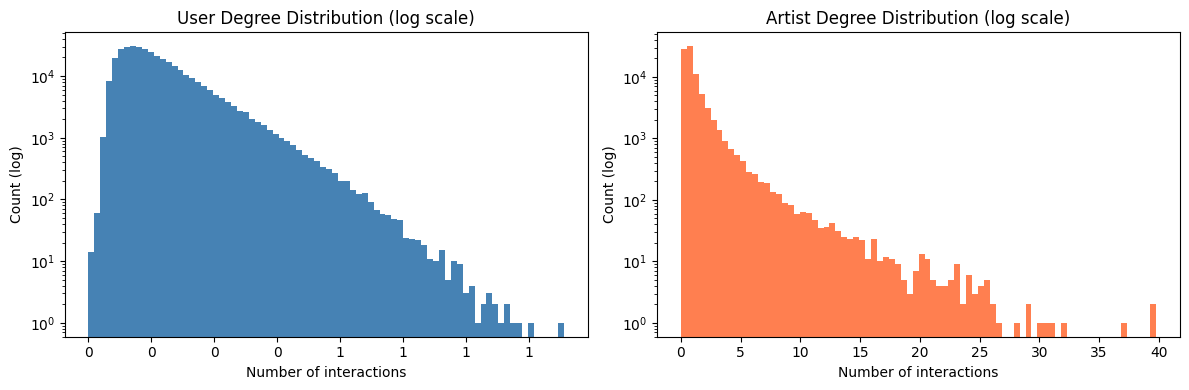

User   — mean: 0.3  median: 0  max: 2
Artist — mean: 1.2  median: 1  max: 40


In [5]:
# ── Degree distribution ───────────────────────────────────────────────────────
A_csr    = A_hat.tocsr()
user_deg = np.asarray(A_csr[:n_users].sum(axis=1)).flatten()
item_deg = np.asarray(A_csr[n_users:].sum(axis=1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, deg, label, colour in zip(
    axes,
    [user_deg, item_deg],
    ["User", "Artist"],
    ["steelblue", "coral"],
):
    ax.hist(deg, bins=80, color=colour, edgecolor="none", log=True)
    ax.set_title(f"{label} Degree Distribution (log scale)")
    ax.set_xlabel("Number of interactions")
    ax.set_ylabel("Count (log)")
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

plt.tight_layout()
plt.show()

for label, deg in [("User  ", user_deg), ("Artist", item_deg)]:
    print(f"{label} — mean: {deg.mean():.1f}  median: {np.median(deg):.0f}"
          f"  max: {deg.max():.0f}")

## 3. LightGCN Model

In [6]:
class LightGCN(nn.Module):
    """
    LightGCN: Simplifying and Powering Graph Convolution Network for Recommendation.
    He et al., SIGIR 2020 — https://arxiv.org/abs/2002.02126

    Only trainable parameters: initial embedding table E^(0) of shape (N, d).

    Forward:
        E^(k)  = A_hat @ E^(k-1)
        E_final = mean( E^(0), ..., E^(K) )

    Training: BPR loss + L2 regularisation on E^(0).
    """

    def __init__(
        self,
        n_users:       int,
        n_items:       int,
        embedding_dim: int,
        n_layers:      int,
        adj:           torch.Tensor,
    ):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers
        self.adj = adj  # sparse, lives on CPU

        self.embedding = nn.Embedding(n_users + n_items, embedding_dim)
        nn.init.normal_(self.embedding.weight, std=0.1)

    # ------------------------------------------------------------------
    def propagate(self) -> torch.Tensor:
        """
        K-layer light graph convolution.
        Returns E_final of shape (n_users + n_items, d).
        Sparse matmul runs on CPU regardless of DEVICE.
        """
        E      = self.embedding.weight.cpu()  # bring to CPU for sparse mm
        layers = [E]
        for _ in range(self.n_layers):
            E = torch.sparse.mm(self.adj, E)
            layers.append(E)
        # Mean pooling over layers 0 … K
        return torch.stack(layers, dim=0).mean(dim=0)

    # ------------------------------------------------------------------
    @torch.no_grad()
    def get_embeddings(self) -> tuple[torch.Tensor, torch.Tensor]:
        """Return (user_emb, item_emb) for evaluation / inference."""
        E = self.propagate()
        return E[: self.n_users], E[self.n_users :]


def bpr_loss(
    u_emb: torch.Tensor,
    p_emb: torch.Tensor,
    n_emb: torch.Tensor,
    u0:    torch.Tensor,
    p0:    torch.Tensor,
    n0:    torch.Tensor,
    lam:   float,
) -> torch.Tensor:
    """
    BPR loss + L2 regularisation on *initial* embeddings (u0, p0, n0).

    Args:
        u_emb, p_emb, n_emb: final (propagated) embeddings for the batch.
        u0, p0, n0:          initial (layer-0) embeddings for the batch.
        lam:                 L2 regularisation coefficient.
    """
    pos   = (u_emb * p_emb).sum(-1)
    neg   = (u_emb * n_emb).sum(-1)
    loss  = -F.logsigmoid(pos - neg).mean()
    reg   = lam * (u0.norm(2).pow(2) + p0.norm(2).pow(2) + n0.norm(2).pow(2)) / len(u_emb)
    return loss + reg

## 4. Training Utilities

In [7]:
class BPRSampler:
    """
    Fast sampler for (user, pos_item, neg_item) triplets.

    Positive items are sampled uniformly from each user's training history.
    Negative items are sampled uniformly from all items (no rejection filtering —
    the probability of accidentally sampling a true positive is ~0.04%).
    """

    def __init__(self, users: np.ndarray, items: np.ndarray, n_items: int):
        self.n_items = n_items
        print("Building user → positive items index ...")
        t0 = time.time()

        # Group positive items by user
        order = np.argsort(users)
        u_sorted, i_sorted = users[order], items[order]
        boundaries = np.where(np.diff(u_sorted) != 0)[0] + 1
        user_ids   = np.split(u_sorted, boundaries)
        item_lists = np.split(i_sorted, boundaries)

        self.user_pos  = {int(uid[0]): arr for uid, arr in zip(user_ids, item_lists)}
        self.train_users = np.array(list(self.user_pos.keys()), dtype=np.int64)

        print(f"  {len(self.train_users):,} users  ({time.time() - t0:.1f}s)")

    def sample(self, batch_size: int):
        users     = np.random.choice(self.train_users, size=batch_size)
        pos_items = np.array([
            self.user_pos[u][np.random.randint(len(self.user_pos[u]))]
            for u in users
        ], dtype=np.int64)
        neg_items = np.random.randint(0, self.n_items, size=batch_size, dtype=np.int64)
        return (
            torch.from_numpy(users),
            torch.from_numpy(pos_items),
            torch.from_numpy(neg_items),
        )

In [8]:
def evaluate(
    model:        LightGCN,
    test_u:       np.ndarray,
    test_i:       np.ndarray,
    train_u:      np.ndarray,
    train_i:      np.ndarray,
    n_items:      int,
    k_list:       list[int] | None = None,
    n_eval_users: int = 500,
) -> dict[str, float]:
    """
    Compute Recall@k and NDCG@k on held-out test interactions.

    Scores all n_items candidates per test user (training items are masked).
    Evaluates on a random sample of test users for speed.
    """
    if k_list is None:
        k_list = EVAL_K
    max_k = max(k_list)

    # Build positive maps
    test_pos  = defaultdict(list)
    for u, i in zip(test_u, test_i):
        test_pos[int(u)].append(int(i))

    train_pos = defaultdict(set)
    for u, i in zip(train_u, train_i):
        train_pos[int(u)].add(int(i))

    sampled = np.random.choice(
        list(test_pos.keys()),
        size=min(n_eval_users, len(test_pos)),
        replace=False,
    )

    model.eval()
    with torch.no_grad():
        user_emb, item_emb = model.get_embeddings()

    recalls = {k: [] for k in k_list}
    ndcgs   = {k: [] for k in k_list}

    for u in tqdm(sampled, desc="Evaluating", leave=False):
        true_set = set(test_pos[u])
        if not true_set:
            continue

        # Score all items; mask training positives
        scores = user_emb[u] @ item_emb.T          # (n_items,)
        for i in train_pos.get(u, []):
            scores[i] = float("-inf")

        topk = scores.topk(max_k).indices.cpu().numpy()

        for k in k_list:
            rec  = topk[:k]
            hits = [1 if item in true_set else 0 for item in rec]

            recalls[k].append(sum(hits) / min(len(true_set), k))

            dcg  = sum(h / np.log2(r + 2) for r, h in enumerate(hits))
            idcg = sum(1.0 / np.log2(r + 2) for r in range(min(len(true_set), k)))
            ndcgs[k].append(dcg / idcg if idcg > 0 else 0.0)

    return {
        **{f"Recall@{k}": float(np.mean(recalls[k])) for k in k_list},
        **{f"NDCG@{k}":   float(np.mean(ndcgs[k]))   for k in k_list},
    }

## 5. Train

In [9]:
model = LightGCN(
    n_users=n_users,
    n_items=n_items,
    embedding_dim=EMBEDDING_DIM,
    n_layers=N_LAYERS,
    adj=adj,
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

n_params = sum(p.numel() for p in model.parameters())
print(f"LightGCN — {n_params:,} parameters")
print(f"  Embedding table : {n_users + n_items:,} nodes × {EMBEDDING_DIM} dim")
print(f"  Propagation     : {N_LAYERS} layers")
print(f"  Adj. nnz        : {adj._nnz():,}")
print(f"  Device          : {DEVICE}")

sampler = BPRSampler(train_users, train_items, n_items)

LightGCN — 57,123,712 parameters
  Embedding table : 446,279 nodes × 128 dim
  Propagation     : 3 layers
  Adj. nnz        : 27,477,064
  Device          : mps
Building user → positive items index ...
  358,618 users  (2.3s)


In [10]:
# ── Training loop ─────────────────────────────────────────────────────────────
#
# Strategy: per-epoch graph propagation + mini-batch BPR.
#
#   1. Once per epoch: compute E_final = propagate(E^(0))  [sparse matmul — the
#      bottleneck; run once, not once-per-batch].
#   2. For STEPS_PER_EPOCH mini-batches: index into E_final, compute BPR loss,
#      call loss.backward(retain_graph=True) to accumulate gradients in E^(0).
#   3. One optimizer.step() at the end of the epoch.
#
# This gives the correct gradient for E^(0) while amortising the cost of the
# full sparse propagation across all steps in the epoch.

history: dict[str, list] = {"epoch": [], "loss": [], "metrics": []}

print(f"Training  : {N_EPOCHS} epochs × {STEPS_PER_EPOCH} steps × {BATCH_SIZE} triplets")
print(f"Evaluation: every {EVAL_EVERY} epochs on {N_EVAL_USERS} sampled test users")
print()

for epoch in trange(1, N_EPOCHS + 1, desc="Epochs"):
    model.train()
    optimizer.zero_grad()

    # ── Full propagation (once per epoch) ─────────────────────────────────────
    E        = model.propagate()          # (N, d)  — computation graph is alive
    user_emb = E[: n_users]
    item_emb = E[n_users :]

    epoch_loss = 0.0
    for step in range(STEPS_PER_EPOCH):
        users, pos_items, neg_items = sampler.sample(BATCH_SIZE)

        u    = user_emb[users]
        p    = item_emb[pos_items]
        n_e  = item_emb[neg_items]

        # Initial (layer-0) embeddings for L2 regularisation
        u0   = model.embedding.weight[users]
        p0   = model.embedding.weight[n_users + pos_items]
        n0   = model.embedding.weight[n_users + neg_items]

        loss = bpr_loss(u, p, n_e, u0, p0, n0, LAMBDA_REG)

        # Scale so accumulated gradient equals the epoch-average gradient
        (loss / STEPS_PER_EPOCH).backward(retain_graph=(step < STEPS_PER_EPOCH - 1))
        epoch_loss += loss.item()

    optimizer.step()

    avg_loss = epoch_loss / STEPS_PER_EPOCH
    history["epoch"].append(epoch)
    history["loss"].append(avg_loss)

    if epoch % EVAL_EVERY == 0 or epoch == 1:
        metrics = evaluate(
            model, test_users, test_items,
            train_users, train_items,
            n_items, k_list=EVAL_K, n_eval_users=N_EVAL_USERS,
        )
        history["metrics"].append((epoch, metrics))
        mstr = "  ".join(f"{k}: {v:.4f}" for k, v in metrics.items())
        tqdm.write(f"[Epoch {epoch:3d}]  loss: {avg_loss:.4f}  |  {mstr}")

print("\nDone.")

Training  : 200 epochs × 2048 steps × 4096 triplets
Evaluation: every 5 epochs on 3000 sampled test users



Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
eval_epochs = [e for e, _ in history["metrics"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history["epoch"], history["loss"], color="steelblue", linewidth=1.5)
axes[0].set_title("BPR Loss (train)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# Recall@k
for k in EVAL_K:
    vals = [m[f"Recall@{k}"] for _, m in history["metrics"]]
    axes[1].plot(eval_epochs, vals, label=f"@{k}", linewidth=1.5)
axes[1].set_title("Recall@k (test)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

# NDCG@k
for k in EVAL_K:
    vals = [m[f"NDCG@{k}"] for _, m in history["metrics"]]
    axes[2].plot(eval_epochs, vals, label=f"@{k}", linewidth=1.5)
axes[2].set_title("NDCG@k (test)")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Final Evaluation

In [ ]:
print(f"Evaluating on {N_EVAL_USERS} sampled test users ...")
final = evaluate(
    model, test_users, test_items,
    train_users, train_items,
    n_items, k_list=EVAL_K, n_eval_users=N_EVAL_USERS,
)

print()
header = f"{'Metric':<12}  {'Score':>8}"
print(header)
print("-" * len(header))
for name, val in final.items():
    print(f"{name:<12}  {val:>8.4f}")

## 7. Generate Recommendations

Look up artist names from the raw dataset (if available), then recommend top-K artists for a sample user.

In [ ]:
# ── Load artist name mapping (optional) ──────────────────────────────────────
# The dataset notebook mapped artist_mbid → item_idx using pandas categoricals.
# We reconstruct the same mapping here by replaying the same filtering steps.

DATASET_DIR = Path("../dataset")
PLAYS_FILE  = DATASET_DIR / "usersha1-artmbid-artname-plays.tsv"

idx_to_artist: dict[int, str] = {}

if PLAYS_FILE.exists():
    print("Loading artist names from raw dataset ...")
    t0   = time.time()
    raw  = pd.read_csv(
        PLAYS_FILE,
        sep="\t", header=None,
        names=["user_sha1", "artist_mbid", "artist_name", "plays"],
    )
    # Replay the same pre-processing as rec_dataset.ipynb
    raw  = raw.dropna(subset=["artist_mbid"])
    raw  = raw[raw["artist_mbid"].str.len() > 0]
    raw  = raw.drop_duplicates(subset=["user_sha1", "artist_mbid"])
    raw["item_idx"] = raw["artist_mbid"].astype("category").cat.codes

    idx_to_artist = (
        raw.drop_duplicates("item_idx")
           .set_index("item_idx")["artist_name"]
           .to_dict()
    )
    print(f"  {len(idx_to_artist):,} artists loaded in {time.time() - t0:.1f}s")
else:
    print(f"Raw dataset not found at {PLAYS_FILE}.")
    print("Recommendations will display item indices instead of artist names.")

In [ ]:
def recommend(
    user_id:       int,
    model:         LightGCN,
    train_u:       np.ndarray,
    train_i:       np.ndarray,
    idx_to_artist: dict[int, str],
    k:             int = 10,
) -> list[tuple[int, float, str]]:
    """Return top-k recommended artists for a user (excluding training artists)."""
    model.eval()
    with torch.no_grad():
        user_emb, item_emb = model.get_embeddings()
        scores = user_emb[user_id] @ item_emb.T    # (n_items,)

    # Mask training positives
    seen = set(train_i[train_u == user_id].tolist())
    for i in seen:
        scores[i] = float("-inf")

    topk = scores.topk(k)
    return [
        (
            int(idx),
            float(topk.values[r]),
            idx_to_artist.get(int(idx), f"item_{idx}"),
        )
        for r, idx in enumerate(topk.indices)
    ]


# ── Demo ──────────────────────────────────────────────────────────────────────
DEMO_USER = 0

# Artists the user already listens to
mask       = train_users == DEMO_USER
known_idxs = train_items[mask]
print(f"User {DEMO_USER} — {len(known_idxs):,} training artists (sample):")
for i in known_idxs[:8]:
    name = idx_to_artist.get(int(i), f"item_{i}")
    print(f"  • {name}  (idx={i})")

print(f"\nTop-10 recommendations:")
recs = recommend(DEMO_USER, model, train_users, train_items, idx_to_artist, k=10)
for rank, (idx, score, name) in enumerate(recs, 1):
    print(f"  {rank:2d}. {name:<40s}  score: {score:.3f}")

## 8. Save Model & Embeddings

In [ ]:
SAVE_DIR = DATA_DIR / "model"
SAVE_DIR.mkdir(exist_ok=True)

# ── PyTorch checkpoint ────────────────────────────────────────────────────────
ckpt_path = SAVE_DIR / "resonate.pt"
torch.save(
    {
        "state_dict":    model.state_dict(),
        "n_users":       n_users,
        "n_items":       n_items,
        "embedding_dim": EMBEDDING_DIM,
        "n_layers":      N_LAYERS,
        "history":       history,
        "final_metrics": final,
    },
    ckpt_path,
)
print(f"Checkpoint saved → {ckpt_path}")

# ── Pre-computed embeddings (for fast inference) ──────────────────────────────
with torch.no_grad():
    user_emb, item_emb = model.get_embeddings()

emb_path = SAVE_DIR / "embeddings.npz"
np.savez_compressed(
    emb_path,
    user_emb=user_emb.numpy().astype(np.float32),
    item_emb=item_emb.numpy().astype(np.float32),
)
print(f"Embeddings saved  → {emb_path}")
print(f"  user_emb : {tuple(user_emb.shape)}")
print(f"  item_emb : {tuple(item_emb.shape)}")

# ── How to reload ─────────────────────────────────────────────────────────────
print("\n# To reload the model:")
print("#   ckpt  = torch.load('data/model/resonate.pt', weights_only=False)")
print("#   model = LightGCN(n_users, n_items, EMBEDDING_DIM, N_LAYERS, adj)")
print("#   model.load_state_dict(ckpt['state_dict'])")